<a href="https://colab.research.google.com/github/karanSmhadgut/CSL701-CE_23_Machine-Learning-Lab/blob/main/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Karan Sameer Mhadgut

Batch : CE2

Roll Number : CE23



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from matplotlib.collections import LineCollection
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree, connected_components

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score,
                             adjusted_rand_score,
                             normalized_mutual_info_score)

# Load dataset (upload brca.csv when the file picker appears)
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("brca.csv")
print(df.head())

Saving brca.csv to brca.csv
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0            0.047810           0.1885  ...            19.26

# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

Shape of dataset: (569, 32)

Column names:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']

Data types:
float64    30
int64       1
object      1
Name: count, dtype: int64

Total missing values: 0

Statistical summary (first 6 columns):
       Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  \
count  569.000000     569.000000      569.000000        569.000000   
mean   285.000000      14.127292       19.289649         91.969033   
std

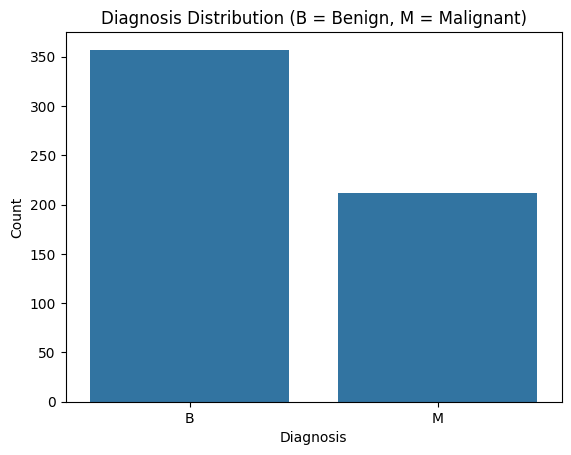

In [ ]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes.value_counts())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nStatistical summary (first 6 columns):")
print(df.iloc[:, :6].describe())

print("\nDiagnosis (y) distribution:")
print(df["y"].value_counts())

sns.countplot(x="y", data=df)
plt.title("Diagnosis Distribution (B = Benign, M = Malignant)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
df = df.drop(columns=["Unnamed: 0"])
df.columns = [c.replace("x.", "") for c in df.columns]
df = df.rename(columns={"y": "diagnosis"})

# Ground-truth labels (used ONLY for evaluation)
y_true = df["diagnosis"].map({"B": 0, "M": 1}).values

# Feature matrix (30 numeric features)
X = df.drop(columns="diagnosis")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Mean of first 5 scaled features:", X_scaled.mean(axis=0)[:5].round(3))
print("Std  of first 5 scaled features:", X_scaled.std(axis=0)[:5].round(3))

Feature matrix shape: (569, 30)
Mean of first 5 scaled features: [-0. -0. -0. -0.  0.]
Std  of first 5 scaled features: [1. 1. 1. 1. 1.]


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
n = X_scaled.shape[0]

dist_vector = pdist(X_scaled, metric="euclidean")
dist_matrix = squareform(dist_vector)

print("Distance matrix shape:", dist_matrix.shape)
print("Number of edges in the complete graph:", len(dist_vector), "= n(n-1)/2 =", n * (n - 1) // 2)
print("Smallest edge weight:", dist_vector.min().round(4))
print("Largest edge weight :", dist_vector.max().round(4))
print("Pairs of identical samples (distance 0):", int((dist_vector == 0).sum()))

Distance matrix shape: (569, 569)
Number of edges in the complete graph: 161596 = n(n-1)/2 = 161596
Smallest edge weight: 1.0061
Largest edge weight : 26.882
Pairs of identical samples (distance 0): 0


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
mst_sparse = minimum_spanning_tree(csr_matrix(dist_matrix))
mst_coo = mst_sparse.tocoo()

mst_edges = (pd.DataFrame({"u": mst_coo.row, "v": mst_coo.col, "weight": mst_coo.data})
               .sort_values("weight", ascending=False)
               .reset_index(drop=True))

print("Number of MST edges:", len(mst_edges), "(must be n - 1 =", n - 1, ")")
print("Total MST weight:", mst_edges["weight"].sum().round(4))
print("\nFive largest MST edges:")
print(mst_edges.head())

# Cross-check with NetworkX
G_full = nx.from_numpy_array(dist_matrix)
mst_nx = nx.minimum_spanning_tree(G_full, algorithm="kruskal")
print("\nNetworkX MST total weight:", round(mst_nx.size(weight="weight"), 4))

Number of MST edges: 568 (must be n - 1 = 568 )
Total MST weight: 1393.8521

Five largest MST edges:
     u    v     weight
0  544  553  12.299945
1   18   69  10.476075
2   48  468   8.826434
3  467  544   8.268542
4  424  429   8.077984

NetworkX MST total weight: 1393.8521


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
def mst_clusters(edges, n_samples, k):
    """Remove the (k-1) largest MST edges and return component labels."""
    kept = edges.iloc[k - 1:]                       # edges are sorted descending
    graph = csr_matrix((kept["weight"], (kept["u"], kept["v"])),
                       shape=(n_samples, n_samples))
    n_comp, labels = connected_components(graph, directed=False)
    return labels

K = 2
labels_mst = mst_clusters(mst_edges, n, K)

print("Edge removed (weight):", mst_edges.loc[0, "weight"].round(4))
print("Cluster sizes:", np.bincount(labels_mst))


def mst_cut_min_size(edges, n_samples, min_size):
    """Cut the single heaviest MST edge whose removal leaves both parts >= min_size."""
    for i in range(len(edges)):
        kept = edges.drop(index=i)
        graph = csr_matrix((kept["weight"], (kept["u"], kept["v"])),
                           shape=(n_samples, n_samples))
        _, labels = connected_components(graph, directed=False)
        if np.bincount(labels).min() >= min_size:
            return labels, edges.loc[i, "weight"], i
    raise ValueError("No edge satisfies the minimum cluster size")

min_size = int(0.10 * n)
labels_mst_min, cut_weight, cut_idx = mst_cut_min_size(mst_edges, n, min_size)

print("Minimum cluster size:", min_size)
print("Edge removed (weight):", round(cut_weight, 4), "- rank", cut_idx + 1, "among the", len(mst_edges), "MST edges (1 = heaviest)")
print("Cluster sizes:", np.bincount(labels_mst_min))

Edge removed (weight): 12.2999
Cluster sizes: [567   2]
Minimum cluster size: 56
Edge removed (weight): 2.3249 - rank 232 among the 568 MST edges (1 = heaviest)
Cluster sizes: [452 117]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
def evaluate(name, labels):
    return {"Method": name,
            "Cluster sizes": str(np.bincount(labels).tolist()),
            "Silhouette": round(silhouette_score(X_scaled, labels), 3),
            "ARI": round(adjusted_rand_score(y_true, labels), 3),
            "NMI": round(normalized_mutual_info_score(y_true, labels), 3)}

labels_km = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_scaled)

results = pd.DataFrame([
    evaluate("MST, cut largest edge (Task 6)", labels_mst),
    evaluate("MST, cut with min cluster size (Task 6B)", labels_mst_min),
    evaluate("K-Means (reference only)", labels_km),
])
print(results.to_string(index=False))

                                  Method Cluster sizes  Silhouette   ARI   NMI
          MST, cut largest edge (Task 6)      [567, 2]       0.661 0.005 0.010
MST, cut with min cluster size (Task 6B)    [452, 117]       0.305 0.430 0.431
                K-Means (reference only)    [375, 194]       0.343 0.654 0.532


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

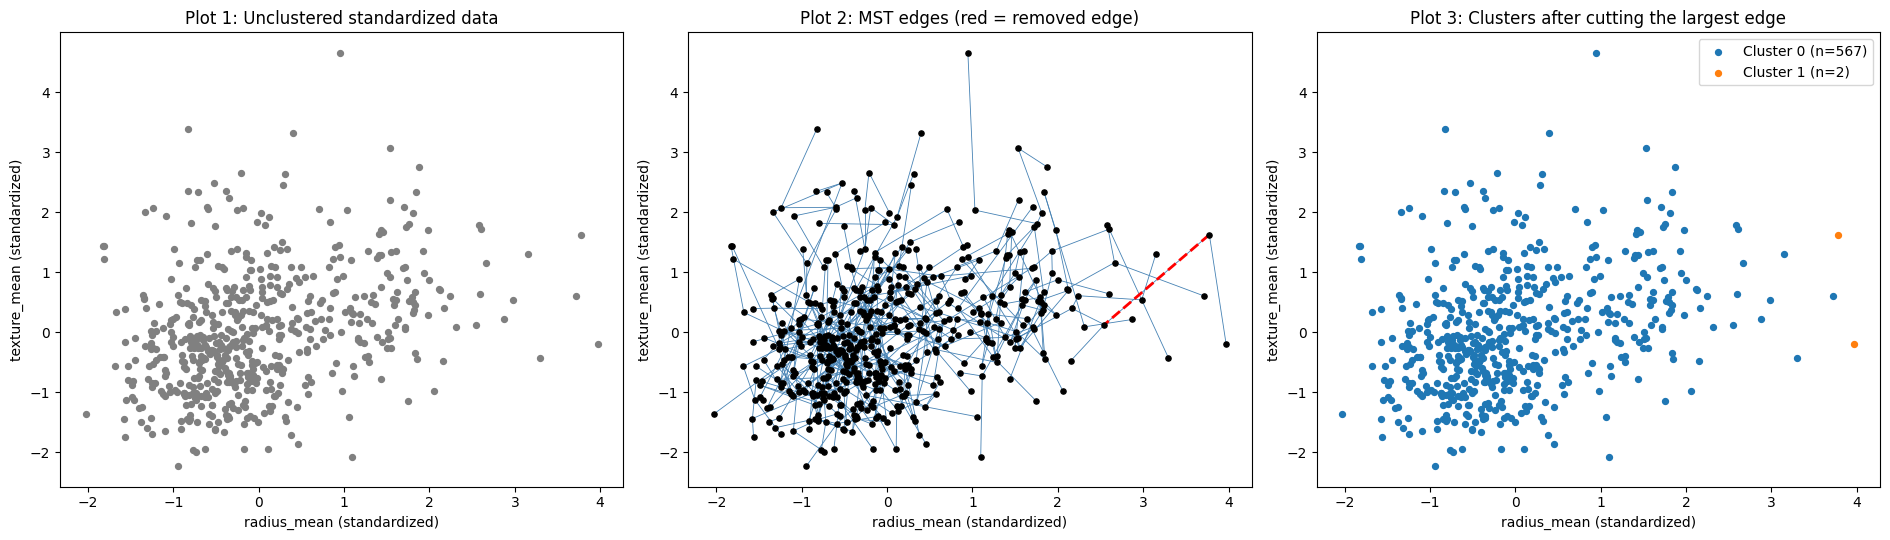

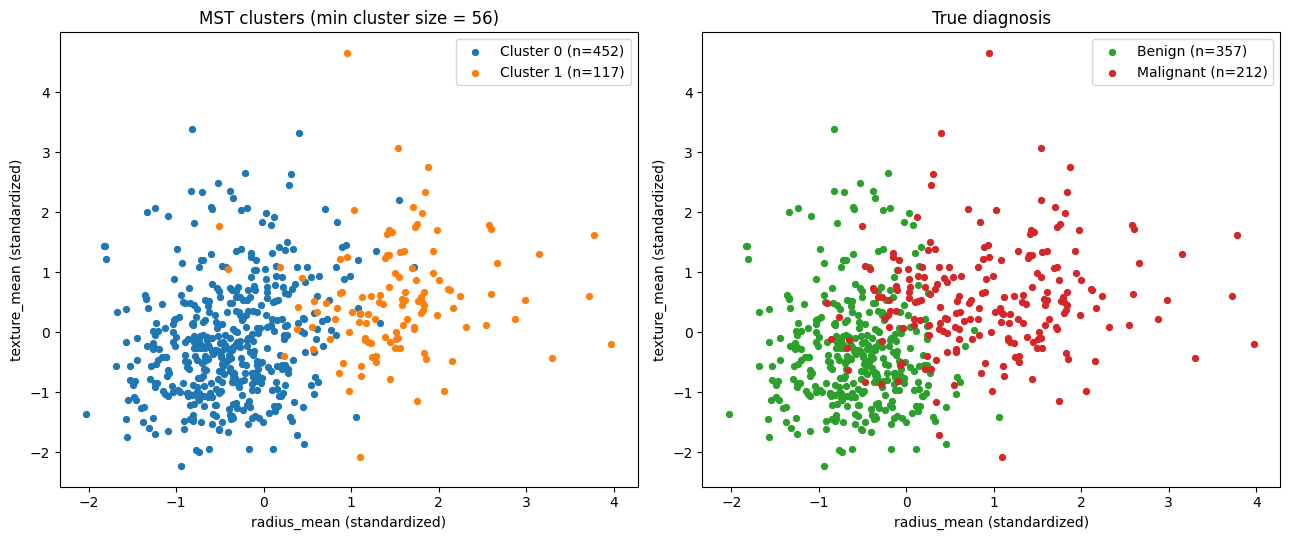

In [ ]:
f1 = X.columns.get_loc("radius_mean")
f2 = X.columns.get_loc("texture_mean")
P = X_scaled[:, [f1, f2]]

# Line segments for every MST edge (in the 2-D projection)
segments = [[P[u], P[v]] for u, v in zip(mst_edges["u"], mst_edges["v"])]
removed = segments[:K - 1]          # the K-1 heaviest edges that Task 6 removes

fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))

# Plot 1: unclustered data
ax[0].scatter(P[:, 0], P[:, 1], s=18, color="gray")
ax[0].set_title("Plot 1: Unclustered standardized data")

# Plot 2: MST overlay
ax[1].add_collection(LineCollection(segments, colors="steelblue", linewidths=0.6))
ax[1].add_collection(LineCollection(removed, colors="red", linewidths=2, linestyles="--"))
ax[1].scatter(P[:, 0], P[:, 1], s=14, color="black", zorder=3)
ax[1].set_title("Plot 2: MST edges (red = removed edge)")

# Plot 3: clusters after cutting K-1 largest edge(s)
for c, col in zip(np.unique(labels_mst), ["tab:blue", "tab:orange"]):
    m = labels_mst == c
    ax[2].scatter(P[m, 0], P[m, 1], s=18, color=col, label=f"Cluster {c} (n={m.sum()})")
ax[2].set_title("Plot 3: Clusters after cutting the largest edge")
ax[2].legend()

for a in ax:
    a.set_xlabel("radius_mean (standardized)")
    a.set_ylabel("texture_mean (standardized)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

for c, col in zip(np.unique(labels_mst_min), ["tab:blue", "tab:orange"]):
    m = labels_mst_min == c
    ax[0].scatter(P[m, 0], P[m, 1], s=18, color=col, label=f"Cluster {c} (n={m.sum()})")
ax[0].set_title("MST clusters (min cluster size = %d)" % min_size)
ax[0].legend()

for lab, col, name in [(0, "tab:green", "Benign"), (1, "tab:red", "Malignant")]:
    m = y_true == lab
    ax[1].scatter(P[m, 0], P[m, 1], s=18, color=col, label=f"{name} (n={m.sum()})")
ax[1].set_title("True diagnosis")
ax[1].legend()

for a in ax:
    a.set_xlabel("radius_mean (standardized)")
    a.set_ylabel("texture_mean (standardized)")
plt.tight_layout()
plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.